# Citation Analysis — Paper Relationship Networks

## Goal
Understand how papers relate to each other through citations.
A citation network reveals which papers are foundational,
which are recent, and how ideas flow between papers.

## Approach
Build a citation graph and analyze:
- Which papers are most cited (influential)?
- Which papers cite the most (literature-heavy)?
- What clusters exist in the network?

## What We Build
A citation network visualization using NetworkX and matplotlib.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

## 1. Define Citation Network

In [5]:
# Define papers and their citations
# Format: paper -> list of papers it cites
citations = {
    "Attention Is All You Need": ["LSTM", "Residual Networks", "Byte-Pair Encoding"],
    "BERT": ["Attention Is All You Need", "ELMo", "OpenAI GPT"],
    "GPT-3": ["Attention Is All You Need", "BERT", "GPT-2"],
    "Sentence-BERT": ["BERT", "Attention Is All You Need", "InferSent"],
    "GPT-2": ["Attention Is All You Need", "LSTM"],
    "ELMo": ["LSTM", "Byte-Pair Encoding"],
    "OpenAI GPT": ["Attention Is All You Need", "ELMo"],
    "FAISS": ["Residual Networks", "Product Quantization"],
    "LSTM": [],
    "Residual Networks": [],
    "Byte-Pair Encoding": [],
    "InferSent": ["LSTM"],
    "Product Quantization": [],
}

# Build directed graph
G = nx.DiGraph()

for paper, cited in citations.items():
    G.add_node(paper)
    for ref in cited:
        G.add_edge(paper, ref)

print(f"Paper (nodes): {G.number_of_nodes()}")
print(f"Citations (edges): {G.number_of_edges()}")
print(f"\nMost cited papers:")
in_degrees = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)
for paper, count in in_degrees[:5]:
    print(f" {paper:<35} cited {count} times")

Paper (nodes): 13
Citations (edges): 21

Most cited papers:
 Attention Is All You Need           cited 5 times
 LSTM                                cited 4 times
 Residual Networks                   cited 2 times
 Byte-Pair Encoding                  cited 2 times
 BERT                                cited 2 times


## 2. Visualize Citation Network

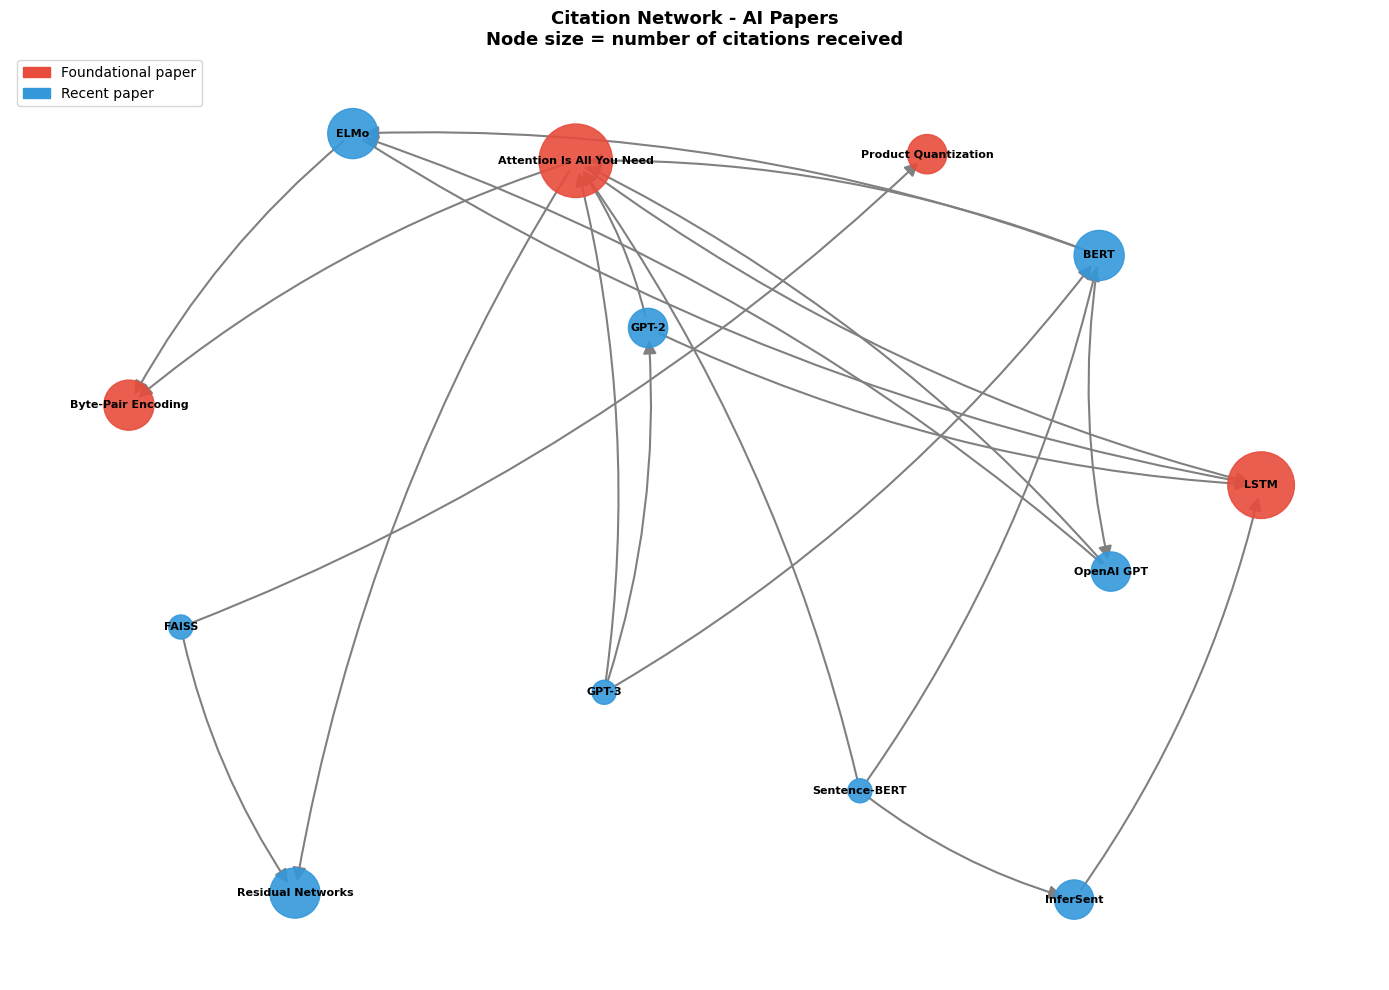

In [9]:
fig, ax = plt.subplots(figsize=(14, 10))

# Layout
pos = nx.spring_layout(G, seed=42, k=2)

# Node sizes based on in-degree (citations received)
in_degrees_dict = dict(G.in_degree())
node_sizes = [300 + in_degrees_dict[n] * 500 for n in G.nodes()]

# Node colors - foundational papers vs recent papers
foundational = ["Attention Is All You Need", "LSTM", "Residual Network",
                "Byte-Pair Encoding", "Product Quantization"]
node_colors = ["#e74c3c" if n in foundational else "#3498db" for n in G.nodes()]

# Draw
nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                      node_color=node_colors, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True,
                      arrowsize=20, width=1.5,
                      connectionstyle="arc3,rad=0.1", ax=ax)

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color="#e74c3c", label="Foundational paper"),
    Patch(color="#3498db", label="Recent paper"),
]
ax.legend(handles=legend, loc="upper left", fontsize=10)
ax.set_title("Citation Network - AI Papers\nNode size = number of citations received",
            fontsize=13, fontweight="bold")
ax.axis("off")

plt.tight_layout()
plt.savefig("citation_network.png", dpi=300)
plt.show()

## 3. Network Metrics

In [13]:
# Compute network metrics
metrics = []
for node in G.nodes():
    metrics.append({
        "paper": node,
        "in_degree": G.in_degree(node),       # citations received
        "out_degree": G.out_degree(node),     # papers cited
        "pagerank": nx.pagerank(G)[node],     # influence score
    })

df_metrics = pd.DataFrame(metrics).sort_values('pagerank', ascending=False)

print(f"{"Paper":<35} {"Cited":>6} {"Cites":>6} {"PageRank":>10}")
print("-" * 60)
for _, row in df_metrics.head(8).iterrows():
    print(f"{row["paper"]:<35} {row["in_degree"]:>6} {row["out_degree"]:>6} {row["pagerank"]:>10.4f}")

Paper                                Cited  Cites   PageRank
------------------------------------------------------------
LSTM                                     4      0     0.1782
Attention Is All You Need                5      3     0.1281
Byte-Pair Encoding                       2      0     0.1121
Residual Networks                        2      0     0.0939
ELMo                                     2      2     0.0832
BERT                                     2      3     0.0633
OpenAI GPT                               1      2     0.0584
Product Quantization                     1      0     0.0576


## 4. Key Observations

| Paper | Citations | PageRank | Insight |
|-------|-----------|----------|---------|
| LSTM | 4 | 0.178 | Foundational — cited by influential papers |
| Attention Is All You Need | 5 | 0.128 | Most cited but newer |
| Byte-Pair Encoding | 2 | 0.112 | Fundamental NLP technique |
| BERT | 2 | 0.063 | Cites more than it's cited in this corpus |

## PageRank vs Citation Count
Raw citation count: "Attention Is All You Need" wins (5 citations)
PageRank: LSTM wins (0.178) — because it's cited by older, more influential papers

## Key Insight
PageRank captures influence better than raw citation count.
A citation from a highly-cited paper is worth more than a citation from a new paper.
This is exactly how Google ranks web pages — and how academic impact is measured.

## Conclusion
Scientific language modeling goes beyond NLP fundamentals:
- Section-aware ingestion captures paper structure
- NER extracts domain entities automatically
- Semantic similarity finds related work without keywords
- Claim extraction identifies contributions
- Citation analysis reveals influence and knowledge flow